# **Capstone Project: [Deteksi Penyakit pada Tanaman Kelapa Sawit]**
**ID Group:** LAI25-RM112

**Anggota Kelompok:**
- A200YBF418_Refanda Surya Saputra - A200YBF418@devacademy.id
- A270YAF435_Risky Fahriza - A270YAF435@devacademy.id
- A528YBF449_Sebastian Luth Hasibuan - A528YBF449@devacademy.id
- A184YBF450_Sefza Auma Alam - A184YBF450@devacademy.id

## **Import Libraries/Packages**

In [2]:
import os
import random
import shutil
import warnings
import zipfile

import dagshub
import mlflow
import cv2
import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import FileLink
from PIL import Image
from skimage import img_as_ubyte
from skimage import io
from skimage.exposure import adjust_gamma
from skimage.transform import rotate, AffineTransform, warp
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.resnet_v2 import ResNet50V2
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, \
    GlobalAveragePooling2D
from tensorflow.keras.layers import Input, Rescaling
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.saved_model import save
from tqdm.notebook import tqdm as tq

warnings.simplefilter(action='ignore', category=FutureWarning)

print(tf.__version__)

2.18.0


## **Init Dagshub**

In [4]:
dagshub.init(repo_owner='refandasuryasaputra', repo_name='CP-Laskar-AI-LAI25-RM112', mlflow=True)

Initialized MLflow to track repo "refandasuryasaputra/CP-Laskar-AI-LAI25-RM112"

Repository refandasuryasaputra/CP-Laskar-AI-LAI25-RM112 initialized!

## **Loading Data**

### **Preparation Data**

#### **Using Kaggle Notebook/Remote Server**

In [5]:
# Ketika menggunakan Kaggle Notebook
kaggle_input_path = '/kaggle/input/palm-disease-dataset/palm-disease-dataset'

kaggle_output_path = '/kaggle/working/palm-disease-dataset'

if not os.path.exists(kaggle_output_path):
    os.makedirs(kaggle_output_path)

try:
    shutil.copytree(kaggle_input_path, kaggle_output_path, dirs_exist_ok=True)
    print(f"Berhasil menyalin dataset dari '{kaggle_input_path}' ke {kaggle_output_path}")
except Exception as e:
    print(f"Unexpected error: {e}")

Berhasil menyalin dataset dari '/kaggle/input/palm-disease-dataset/palm-disease-dataset' ke /kaggle/working/palm-disease-dataset


### **Checking Dataset**

In [6]:
# Mengecek label pada dataset
palm_disease_path = "/kaggle/working/palm-disease-dataset"

# Menyimpan label
list_label = os.listdir(palm_disease_path)

# Menampilkan list label
list_label

['Fungal Disease', 'Magnesium Deficiency', 'Scale Insect', 'Healthy']

In [ ]:
# Membuat dictionary untuk menyimpan gambar untuk setiap kelas dalam data_tf
palm_disease_image = {}

# Menentukan path sumber dataset
source_path = "/kaggle/working/palm-disease-dataset/"

for i in os.listdir(source_path):
    palm_disease_image[i] = os.listdir(source_path + i)

# menampilkan secara acak 5 gambar untuk masing-masing kelas
fig, ax = plt.subplots(4, 5, figsize=(15, 20))

for i, label in enumerate(os.listdir(source_path)):
    images = np.random.choice(palm_disease_image[label], 5, replace=False)
    for j, leaf_image in enumerate(images):
        img_path = os.path.join(source_path, label, leaf_image)
        img = Image.open(img_path)
        ax[i, j].imshow(img)
        ax[i, j].set(xlabel=label, xticks=[], yticks=[])

fig.tight_layout()

In [8]:
# Membuat fungsi untuk melihat jumlah image tiap-tiap kelas
def get_image_count(img_dataset_path):
    image_count = {}
    for img_label in os.listdir(img_dataset_path):
        image_count[img_label] = len(os.listdir(os.path.join(img_dataset_path, img_label)))
    return image_count


# Menentukan path sumber dataset
source_path = "/kaggle/working/palm-disease-dataset/"
print(get_image_count(source_path))

{'Magnesium Deficiency': 59, 'Fungal Disease': 58, 'Healthy': 56, 'Scale Insect': 66}


### **Distribution Plot of Class Dataset**

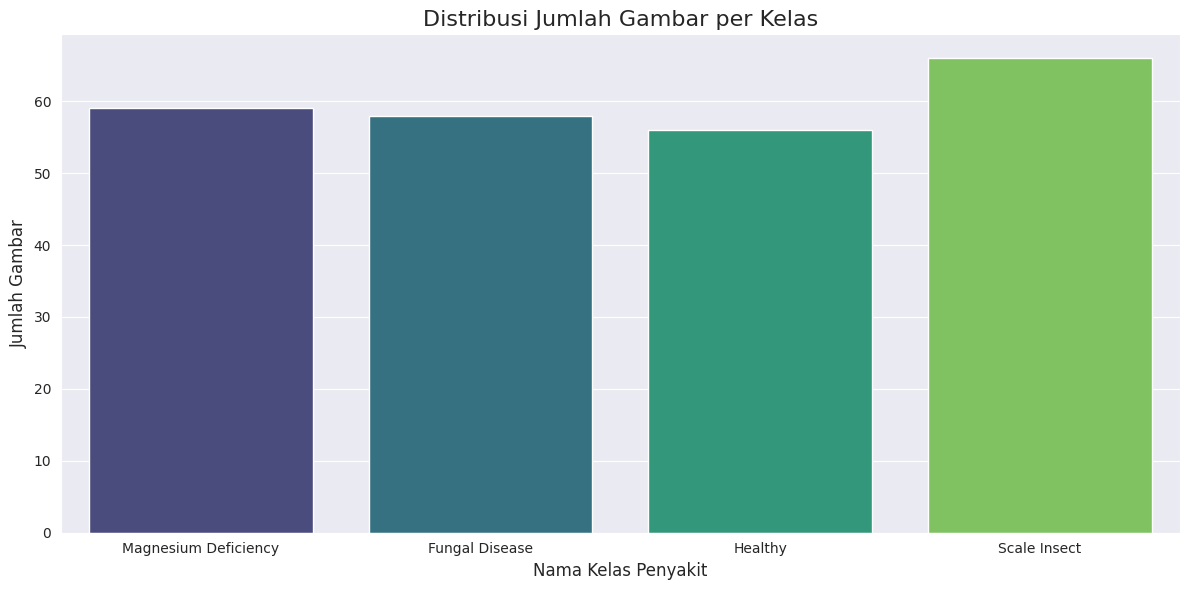

In [9]:
def plot_distribution(path):
    # Membuat daftar yang menyimpan data_tf untuk setiap nama file, path file, dan label dalam data_tf
    file_name = []
    labels = []
    full_path = []

    # Mendapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai DataFrame
    for path, subdirs, files in os.walk(path):
        for name in files:
            file_name.append(name)
            labels.append(path.split('/')[-1])
            full_path.append(os.path.join(path, name))

    distribution_train = pd.DataFrame({
        'path': full_path,
        'file_name': file_name,
        'labels': labels
    })
    for name in files:
        file_name.append(name)
        labels.append(path.split('/')[-1])

    # Plot distribusi gambar setiap kelas
    plt.figure(figsize=(12, 6))
    sns.set_style('darkgrid')
    sns.countplot(data=distribution_train, x='labels', palette='viridis')

    plt.title("Distribusi Jumlah Gambar per Kelas", fontsize=16)
    plt.xlabel("Nama Kelas Penyakit", fontsize=12)
    plt.ylabel("Jumlah Gambar", fontsize=12)
    plt.tight_layout()
    plt.show()


plot_distribution(source_path)

## **Preprocessing Data**

### **Spliting Data**

In [7]:
# Membuat variabel untuk menampung lokasi folder dari dataset gambar
source_path = '/kaggle/working/palm-disease-dataset/'

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(source_path):
    for name in files:
        file_name.append(name)
        labels.append(path.split('/')[-1])
        full_path.append(os.path.join(path, name))

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah DataFrame
image_df = pd.DataFrame({
    'file_name': file_name,
    'labels': labels,
    'full_path': full_path
})

# Melihat jumlah data_tf gambar pada masing-masing label
image_df['labels'].value_counts()

labels
Scale Insect            66
Magnesium Deficiency    59
Fungal Disease          58
Healthy                 56
Name: count, dtype: int64

In [8]:
# variabel yang digunaka pada pemisahan data_tf ini, di mana variabel x = data_tf path dan y = data_tf labels
X = image_df['full_path']
y = image_df['labels']

# Split dataset awal menjadi data_tf train dan temp (test dan validasi)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Menyatukan ke dalam maisng-masing DataFrame
df_train = pd.DataFrame({
    'path': X_train,
    'labels': y_train,
    'set': 'train'
})

df_test = pd.DataFrame({
    'path': X_test,
    'labels': y_test,
    'set': 'test'
})

# Menggabungkan DataFrame df_train, df_test, dan df_validation
df_all = pd.concat([df_train, df_test], ignore_index=True)
print(df_all.groupby(['set', 'labels']).size())

set    labels              
test   Fungal Disease          12
       Healthy                 11
       Magnesium Deficiency    12
       Scale Insect            13
train  Fungal Disease          46
       Healthy                 45
       Magnesium Deficiency    47
       Scale Insect            53
dtype: int64


In [9]:
# Mengecek sampel data_tf
print(df_all.sample(5))

                                                  path        labels    set
136  /kaggle/working/palm-disease-dataset/Scale Ins...  Scale Insect  train
20   /kaggle/working/palm-disease-dataset/Healthy/H...       Healthy  train
72   /kaggle/working/palm-disease-dataset/Healthy/h...       Healthy  train
55   /kaggle/working/palm-disease-dataset/Scale Ins...  Scale Insect  train
139  /kaggle/working/palm-disease-dataset/Scale Ins...  Scale Insect  train


In [10]:
# Memanggil dataset asli yang berisi keseluruhan data_tf gambar yang sesuai dengan labelnya
datasource_path = '/kaggle/working/palm-disease-dataset/'

# Membuat variabel dataset, tempat menampung data_tf yang telah dilakukan splitting
dataset_path = '/kaggle/working/final-dataset/'

for index, row in tq(df_all.iterrows()):
    file_path = row['path']

    if not os.path.exists(file_path):
        file_path = os.path.join(datasource_path, row['labels'], row['image'].split('.')[0])

    # Membuat direktori tujuan folder
    if not os.path.exists(os.path.join(dataset_path, row['set'], row['labels'])):
        os.makedirs(os.path.join(dataset_path, row['set'], row['labels']))

    # Menentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    destination_path = os.path.join(dataset_path, row['set'], row['labels'], destination_file_name)

    # Memindahkan file ke direktori tujuan
    if not os.path.exists(destination_path):
        shutil.copy2(file_path, destination_path)

0it [00:00, ?it/s]

### **Data Augmentation**

In [11]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(raw_image):
    aug_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2BGR)
    aug_image = cv2.resize(aug_image, (224, 224))
    angle = random.randint(0, 180)
    return rotate(aug_image, angle)


# Membuat fungsi untuk melakukan rotasi searah jarum ram
def clockwise_rotation(raw_image):
    aug_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2BGR)
    aug_image = cv2.resize(aug_image, (224, 224))
    angle = random.randint(0, 180)
    return rotate(aug_image, -angle)


# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(raw_image):
    aug_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2BGR)
    aug_image = cv2.resize(aug_image, (224, 224))
    aug_image = adjust_gamma(aug_image, gamma=0.5, gain=1)
    return aug_image

# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(raw_image):
    aug_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2BGR)
    aug_image = cv2.resize(aug_image, (224, 224))
    transform = AffineTransform(shear=0.2)
    shear_img = warp(aug_image, transform, mode='wrap')
    return shear_img


# Membuat fungsi untuk melakukan pergeseran melengkung pada gambar
def warp_shift(raw_image):
    aug_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2BGR)
    aug_image = cv2.resize(aug_image, (224, 224))
    transform = AffineTransform(translation=(0, 40))
    warp_img = warp(aug_image, transform, mode='wrap')
    return warp_img

In [12]:
# Membuat varabel transofrmasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = {
    'anticlockwise_rotation': anticlockwise_rotation,
    'clockwise_rotation': clockwise_rotation,
    'add_brightness': add_brightness,
    'shear_image': sheared,
    'warp_shift': warp_shift
}

def generate_augmented_image(image_class_name, source_image_path, num_augmented_images):
    img_processed_path = os.path.join(source_image_path, image_class_name)

    processed_images = []

    for raw_image in os.listdir(img_processed_path):
        processed_images.append(os.path.join(img_processed_path, raw_image))

    images_to_generate = num_augmented_images - len(os.listdir(img_processed_path))

    i = 1

    while i <= images_to_generate:
        random_image = random.choice(processed_images)

        try:
            original_image = io.imread(random_image)
            transformed_image = None

            num_transformations_to_apply = random.randint(1, len(transformations))

            num_transformations = 0

            while num_transformations <= num_transformations_to_apply:
                key = random.choice(list(transformations))
                transformed_image = transformations[key](original_image)
                num_transformations += 1

            new_image_path = "%s/augmented_image_%s.jpg" % (img_processed_path, i)
            transformed_image = img_as_ubyte(transformed_image)
            cv2.imwrite(new_image_path, transformed_image)
            i += 1
        except Exception as exception:
            print('Could not read the', image, ':', exception, 'hence skipping it.')

In [13]:
source_path = '/kaggle/working/final-dataset/train/'

for label in list_label:
    generate_augmented_image(label, source_path, 300)

print("Berhasil melakukan augmentasi gambar")

Berhasil melakukan augmentasi gambar


### **Set Splitting Directory & Checking Splitting Result**

In [14]:
# Mendefinisikan direktori daset training, test, dan validation
TRAIN_DIR = '/kaggle/working/final-dataset/train'
TEST_DIR = '/kaggle/working/final-dataset/test'
VAL_DIR = '/kaggle/working/final-dataset/validation'

palm_disease_path = "/kaggle/working/palm-disease-dataset"

list_label = os.listdir(palm_disease_path)

# Membuat fungsi untuk menampilkan jumlah data_tf train berdasarkan label
def print_total_train_data(label):
    train_temp = os.path.join(TRAIN_DIR, label)
    train_count = len(os.listdir(train_temp))
    print("Total train data_tf for {} is {}".format(label, train_count))


# Membuat fungsi untuk menampilkan jumlah data_tf test berdasarkan label
def print_total_test_data(label):
    test_temp = os.path.join(TEST_DIR, label)
    test_count = len(os.listdir(test_temp))
    print("Total test data_tf for {} is {}".format(label, test_count))


for label in list_label:
    print_total_train_data(label)
    print_total_test_data(label)
    print("\n")

Total train data_tf for Fungal Disease is 300
Total test data_tf for Fungal Disease is 12


Total train data_tf for Magnesium Deficiency is 300
Total test data_tf for Magnesium Deficiency is 12


Total train data_tf for Scale Insect is 300
Total test data_tf for Scale Insect is 13


Total train data_tf for Healthy is 300
Total test data_tf for Healthy is 11




## **Building Model**

### **Perparing Callbacks**

In [15]:
# Membuat custom callback untuk menghentikan model saat akurasi lebih dari 95%
class EpochCallback(Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('accuracy') > 0.95:
            print("\nAkurasi telah mencapai >95%")
            self.model.stop_training = True


epoch_checkpoint = EpochCallback()

# Membuat callback checkpoint
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Membuat callback early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Membuat callback untuk memperkecil learning_rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=15,
    min_lr=0.000001,
    verbose=1
)

### **Model Experiment 1**

#### **Image Data Generator**

In [16]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [17]:
train_datagen = ImageDataGenerator(
    validation_split=0.3,
)

test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 840 images belonging to 4 classes.
Found 360 images belonging to 4 classes.
Found 48 images belonging to 4 classes.
{'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}


#### **Calculate Class Weight**

In [18]:
# Melakukan perhitungan bobot kelas
class_indices_dictionary = train_generator.class_indices
class_count = len(class_indices_dictionary)

class_weight_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weight_dictionary = dict(enumerate(class_weight_array))

print("class_indices: ", class_indices_dictionary)
print("class weight: ", class_weight_dictionary)

class_indices:  {'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}
class weight:  {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}


In [20]:
# Mengaktifkan autologging
mlflow.tensorflow.autolog(log_models=False)

# Inisialisasi model sekuensial
model_1 = Sequential()

model_1.add(Input(shape=(224, 224, 3)))

model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(GlobalAveragePooling2D())

model_1.add(Dense(256, activation='relu'))
model_1.add(Dropout(0.5))

model_1.add(Dense(len(list_label), activation='softmax'))

opt = Adam(learning_rate=0.0001)

model_1.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# rangkuman arsitektur model
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 224, 224, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 112, 112, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 56, 56, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,214,020 (4.63 MB)

 Trainable params: 1,213,124 (4.63 MB)

 Non-trainable params: 896 (3.50 KB)

In [21]:
# Fitting / training model
with mlflow.start_run():
    history_model_1 = model_1.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, reduce_lr, epoch_checkpoint]
    )

2025/06/12 10:37:49 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 10:37:49 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1749724675.037239     153 service.cc:148] XLA service 0x7ae868025020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749724675.037945     153 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749724675.037975     153 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749724675.580074     153 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1749724699.945348     153 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.3165 - loss: 1.4728

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 1.60074, saving model to best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.3193 - loss: 1.4691 - val_accuracy: 0.2500 - val_loss: 1.6007 - learning_rate: 1.0000e-04
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.5200 - loss: 1.1114
Epoch 2: val_loss improved from 1.60074 to 1.33158, saving model to best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 921ms/step - accuracy: 0.5199 - loss: 1.1113 - val_accuracy: 0.2972 - val_loss: 1.3316 - learning_rate: 1.0000e-04
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.6243 - loss: 0.9609
Epoch 3: val_loss improved from 1.33158 to 1.22844, saving model to best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 935ms/step - accuracy: 0.6242 - loss: 0.9605 - val_accuracy: 0.4306 - val_loss: 1.2284 - learning_rate: 1.0000e-04
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.6559 - loss: 0.8484
Epoch 4: val_loss improved from 1.22844 to 1.14287, saving model

### **Model Transfer Learning (MobileNetV2)**

#### **Image Data Generator**

In [22]:
train_datagen = ImageDataGenerator(
    validation_split=0.3,
)
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 840 images belonging to 4 classes.
Found 360 images belonging to 4 classes.
Found 48 images belonging to 4 classes.
{'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}


#### **Init Model Transfer Learning**

In [23]:
# Melakukan inisiasi model dasar
base_model_tl = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model_tl.trainable = False

# Membuat model baru
inputs = Input(shape=(224, 224, 3))
scale_layer = Rescaling(scale=1 / 127.5, offset=-1)(inputs)

x = base_model_tl(scale_layer, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(len(list_label), activation='softmax')(x)

model_tl = Model(inputs, outputs)
model_tl.summary(show_trainable=True)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_3 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling (Rescaling)               │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ mobilenetv2_1.00_224 (Functional)   │ (None, 7, 7, 1280)           │     2,257,984 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_2          │ (None, 1280)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_4 (Dense)                     │ (None, 4)                    │         5,124 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
# Melatih model MobileNetV2 dengan data_tf baru
model_tl.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

#### **Extraction Features & Fine Tuning**

In [25]:
# Melakukan proses ekstraksi fitur
with mlflow.start_run():

    # Log informasi base model
    mlflow.log_param("base_model", "MobileNetV2")
    mlflow.log_param("base_model_trainable", False)
    mlflow.log_param("new_layers", "Rescaling, GlobalAverage2D, Dense(256), Dense(4)")

    # Log base model summary
    with open("base_model_summary.txt", "w") as f:
        base_model_tl.summary(print_fn=lambda z: f.write(z + "\n"))
    mlflow.log_artifact("base_model_summary.txt")

    # Log model visualization
    tf.keras.utils.plot_model(model_tl, to_file="model_architecture.png", show_shapes=True)
    mlflow.log_artifact("model_architecture.png")

    model_tl.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

    # Memulai proses fine tuning
    base_model_tl.trainable = True
    model_tl.summary(show_trainable=True)

    model_tl.compile(
        optimizer=Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_model_tl = model_tl.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

2025/06/12 10:51:40 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 10:51:40 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.3618 - loss: 1.4903
Epoch 1: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.3672 - loss: 1.4798 - val_accuracy: 0.7111 - val_loss: 0.7800
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7274 - loss: 0.7048
Epoch 2: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 712ms/step - accuracy: 0.7289 - loss: 0.7019 - val_accuracy: 0.7917 - val_loss: 0.5462
Epoch 3/50
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8483 - loss: 0.4692
Epoch 3: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 678ms/step - accuracy: 0.8495 - loss: 0.4669 - val_accuracy: 0.8333 - val_loss: 0.4498
Epoch 4/50
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8817 - loss: 0.3608
Epoch 4: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 678ms/step - accuracy: 0.8823 - loss: 0.3602 - val_accuracy: 0.8583 - val_loss: 0.3923
Ep

Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_3 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling (Rescaling)               │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ mobilenetv2_1.00_224 (Functional)   │ (None, 7, 7, 1280)           │     2,257,984 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_2          │ (None, 1280)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_4 (Dense)                     │ (None, 4)                    │         5,124 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 2,273,358 (8.67 MB)

 Trainable params: 2,228,996 (8.50 MB)

 Non-trainable params: 34,112 (133.25 KB)

 Optimizer params: 10,250 (40.04 KB)

2025/06/12 10:54:11 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 10:54:11 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 10:54:11 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.4625 - loss: 1.5878
Epoch 1: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.4636 - loss: 1.5825 - val_accuracy: 0.8944 - val_loss: 0.2838
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6077 - loss: 1.0239
Epoch 2: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 656ms/step - accuracy: 0.6091 - loss: 1.0203 - val_accuracy: 0.8861 - val_loss: 0.3019
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.7834 - loss: 0.6157
Epoch 3: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 656ms/step - accuracy: 0.7837 - loss: 0.6149 - val_accuracy: 0.8833 - val_loss: 0.3110
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8728 - loss: 0.4198
Epoch 4: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 661ms/step - accuracy: 0.8728 - loss: 0.4194 - val_accuracy: 0.8750 - val_loss: 0.3280

### **Model Transfer Learning (ResNet50)**

#### **Image Data Generator**

In [26]:
train_datagen = ImageDataGenerator(
    validation_split=0.3,
)
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 840 images belonging to 4 classes.
Found 360 images belonging to 4 classes.
Found 48 images belonging to 4 classes.
{'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}


#### **Init Model Transfer Learning**

In [27]:
base_model_resnet = ResNet50V2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

base_model_resnet.trainable = False

input_resnet = Input(shape=(224, 224, 3))
resnet_scale_layer = Rescaling(scale=1 / 127.5, offset=-1)(input_resnet)

x = base_model_resnet(resnet_scale_layer, training=False)
x = GlobalAveragePooling2D()(x)
output = Dense(len(list_label), activation='softmax')(x)

model_resnet = Model(input_resnet, output)
model_resnet.summary(show_trainable=True)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_5 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_1 (Rescaling)             │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ resnet50v2 (Functional)             │ (None, 7, 7, 2048)           │    23,564,800 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_3          │ (None, 2048)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_5 (Dense)                     │ (None, 4)                    │         8,196 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 23,572,996 (89.92 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [28]:
# Melatih model ResNet50V2
model_resnet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

#### **Extraction Feature & Fine Tuning**

In [29]:
# Melakukan proses ekstraksi fitur
with mlflow.start_run():

    # Log informasi base model
    mlflow.log_param("base_model", "ResNest50V2")
    mlflow.log_param("base_model_trainable", False)
    mlflow.log_param("new_layers", "Rescaling, GlobalAverage2D, Dense(256), Dense(4)")

    model_resnet.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

    # Memulai proses fine tuninng
    base_model_resnet.trainable = True
    model_resnet.summary(show_trainable=True)

    model_resnet.compile(
        optimizer=Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_model_resnet = model_resnet.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

2025/06/12 10:57:58 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 10:57:58 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.4021 - loss: 1.3869
Epoch 1: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4061 - loss: 1.3779 - val_accuracy: 0.7056 - val_loss: 0.7324
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7877 - loss: 0.6030
Epoch 2: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 900ms/step - accuracy: 0.7885 - loss: 0.6017 - val_accuracy: 0.8167 - val_loss: 0.5024
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8776 - loss: 0.4190
Epoch 3: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 845ms/step - accuracy: 0.8776 - loss: 0.4187 - val_accuracy: 0.8556 - val_loss: 0.4198
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9300 - loss: 0.3163
Epoch 4: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 840ms/step - accuracy: 0.9296 - loss: 0.3164 - val_accuracy: 0.8611 - val_loss: 0.3809
Ep

Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_5 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_1 (Rescaling)             │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ resnet50v2 (Functional)             │ (None, 7, 7, 2048)           │    23,564,800 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_3          │ (None, 2048)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_5 (Dense)                     │ (None, 4)                    │         8,196 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 23,589,390 (89.99 MB)

 Trainable params: 23,527,556 (89.75 MB)

 Non-trainable params: 45,440 (177.50 KB)

 Optimizer params: 16,394 (64.04 KB)

2025/06/12 11:01:03 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 11:01:03 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 11:01:03 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6240 - loss: 0.8971
Epoch 1: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6264 - loss: 0.8928 - val_accuracy: 0.8694 - val_loss: 0.3385
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.8985 - loss: 0.3647
Epoch 2: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 850ms/step - accuracy: 0.8991 - loss: 0.3637 - val_accuracy: 0.8667 - val_loss: 0.3589
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9775 - loss: 0.1871
Epoch 3: val_loss did not improve from 0.28134

Akurasi telah mencapai >95%
27/27 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9775 - loss: 0.1867 - val_accuracy: 0.8889 - val_loss: 0.3232
🏃 View run delicate-hen-939 at: https://dagshub.com/refandasuryasaputra/CP-Laskar-AI-LAI25-RM112.mlflow/#/experiments/0/runs/b298260693a14aeeafdcb03c280bfa8a
🧪 View experiment at: https://dagshub.com/refandasuryasaputra/CP-Las

### **Model Transfer Learning (Xception)**

#### **Image Data Generator**

In [30]:
train_datagen = ImageDataGenerator(
    validation_split=0.3,
)
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 840 images belonging to 4 classes.
Found 360 images belonging to 4 classes.
Found 48 images belonging to 4 classes.
{'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}


#### **Init Model Xception**

In [31]:
base_model_xception = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model_xception.trainable = False

input_xception = Input(shape=(224, 224, 3))
xception_scale_layer = Rescaling(scale=1 / 127.5, offset=-1)(input_xception)

x_xception = base_model_xception(xception_scale_layer, training=False)
x_xception = GlobalAveragePooling2D()(x_xception)
output_xception = Dense(len(list_label), activation='softmax')(x_xception)

model_xception = Model(input_xception, output_xception)
model_xception.summary(show_trainable=True)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_7 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_2 (Rescaling)             │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ xception (Functional)               │ (None, 7, 7, 2048)           │    20,861,480 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_4          │ (None, 2048)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_6 (Dense)                     │ (None, 4)                    │         8,196 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 20,869,676 (79.61 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [32]:
model_xception.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

#### **Extraction Feature & Fine Tuning**

In [33]:
with mlflow.start_run():

    # Log informasi base model
    mlflow.log_param("base_model", "ResNest50V2")
    mlflow.log_param("base_model_trainable", False)
    mlflow.log_param("new_layers", "Rescaling, GlobalAverage2D, Dense(256), Dense(4)")

    model_xception.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

    base_model_xception.trainable = True

    # Fine tuning
    model_xception.summary(show_trainable=True)

    model_xception.compile(
        optimizer=Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_model_xception = model_xception.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

2025/06/12 11:04:12 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 11:04:12 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.4317 - loss: 1.2254
Epoch 1: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.4352 - loss: 1.2211 - val_accuracy: 0.7139 - val_loss: 0.8194
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7124 - loss: 0.7746
Epoch 2: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 907ms/step - accuracy: 0.7138 - loss: 0.7728 - val_accuracy: 0.8111 - val_loss: 0.6368
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8325 - loss: 0.5762
Epoch 3: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 896ms/step - accuracy: 0.8323 - loss: 0.5758 - val_accuracy: 0.8167 - val_loss: 0.5546
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8709 - loss: 0.4887
Epoch 4: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 906ms/step - accuracy: 0.8709 - loss: 0.4882 - val_accuracy: 0.8444 - val_loss: 0.4843

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_7 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_2 (Rescaling)             │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ xception (Functional)               │ (None, 7, 7, 2048)           │    20,861,480 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_4          │ (None, 2048)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_6 (Dense)                     │ (None, 4)                    │         8,196 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 20,886,070 (79.67 MB)

...

Epoch 1/50


E0000 00:00:1749726566.302462     153 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749726566.493266     153 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749726567.875188     153 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749726568.016228     153 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/27 ━━━━━━━━━━━━━━━━━━━━ 14s 586ms/step - accuracy: 0.5078 - loss: 1.1811

E0000 00:00:1749726584.432692     150 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749726584.574779     150 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6025 - loss: 0.9952
Epoch 1: val_loss did not improve from 0.28134
27/27 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6039 - loss: 0.9930 - val_accuracy: 0.9000 - val_loss: 0.2964
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.7867 - loss: 0.6574
Epoch 2: val_loss improved from 0.28134 to 0.27696, saving model to best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7872 - loss: 0.6564 - val_accuracy: 0.9111 - val_loss: 0.2770
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.8967 - loss: 0.4807
Epoch 3: val_loss improved from 0.27696 to 0.25316, saving model to best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8969 - loss: 0.4798 - val_accuracy: 0.9222 - val_loss: 0.2532
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.9215 - loss: 0.3844
Epoch 4: val_loss improved from 0.25316 to 0.22365, saving model to best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 43s 

## **Evaluating Model**

### **Preparing Evaluating**

In [34]:
# Membuat fungsi untuk melakukan plot metrik
def plot_model_result(epochs, acc, val_acc, loss, val_loss):
    plt.plot(epochs, acc, 'r')
    plt.plot(epochs, val_acc, 'b')
    plt.title('Training and validation accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

    plt.plot(epochs, loss, 'r')
    plt.plot(epochs, val_loss, 'b')
    plt.title('Training and validation loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()


# Membuat fungsi untuk melakukan evaluasi model
def print_result_evaluating_model(model):
    # Evaluasi model menggunakan data_tf pengujian
    evaluation_model_1 = model.evaluate(test_generator)

    # Menampilkan hasil evaluasi
    print('Test Loss:', evaluation_model_1[0])
    print('Test Accuracy:', evaluation_model_1[1])


# Membuat fungsi untuk menampilkan confusion matrix
def show_model_report(model):
    test_generator.reset()

    preds_1 = model.predict(test_generator, verbose=0)
    y_pred = preds_1.argmax(axis=1)
    y_true = test_generator.classes

    class_names = list(test_generator.class_indices.keys())

    # Menampilkan confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # Menampilkan classification report
    print(classification_report(y_true, y_pred, target_names=class_names))

### **Evaluating Model 1**

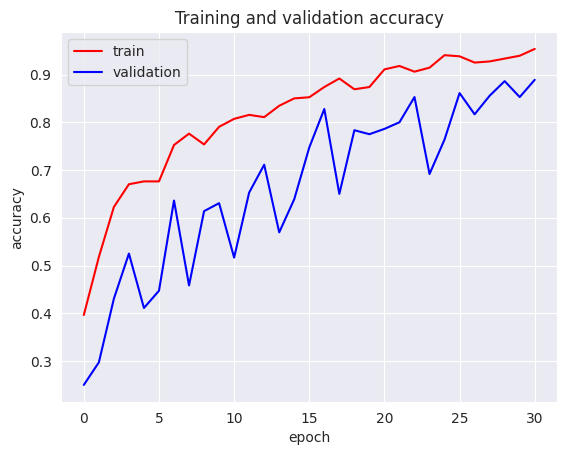

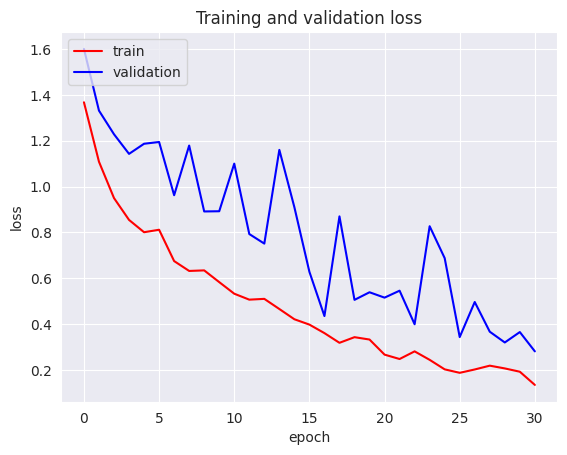

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 9s/step - accuracy: 0.6944 - loss: 1.3503
Test Loss: 1.1762436628341675
Test Accuracy: 0.7291666865348816


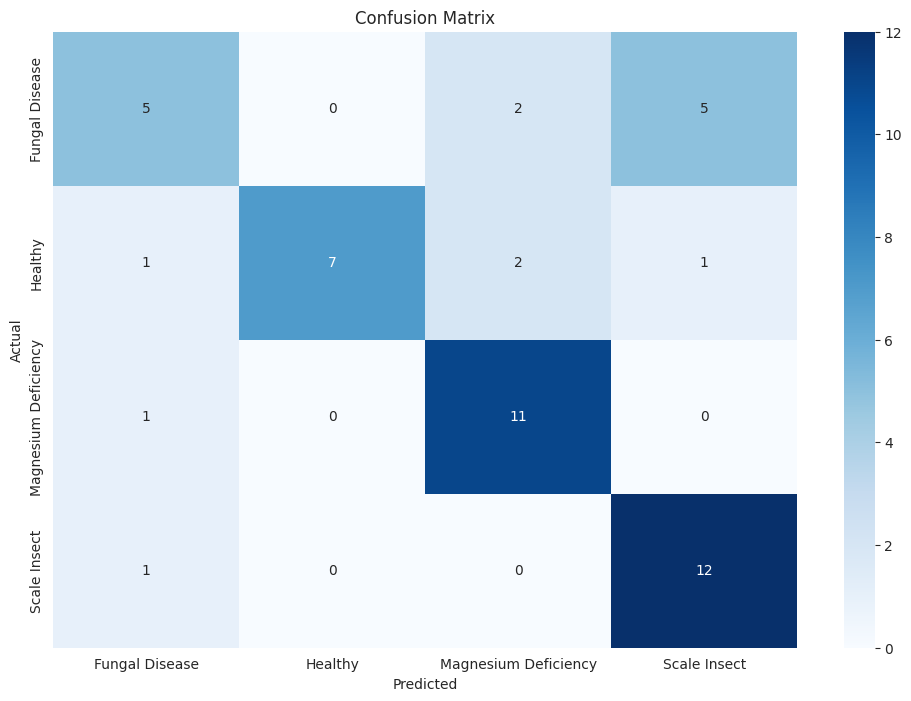

                      precision    recall  f1-score   support

      Fungal Disease       0.62      0.42      0.50        12
             Healthy       1.00      0.64      0.78        11
Magnesium Deficiency       0.73      0.92      0.81        12
        Scale Insect       0.67      0.92      0.77        13

            accuracy                           0.73        48
           macro avg       0.76      0.72      0.72        48
        weighted avg       0.75      0.73      0.72        48



In [35]:
# Menyimpan nilai metrik akurasi dan loss function setelah pelatihan
acc_1 = history_model_1.history['accuracy']
val_acc_1 = history_model_1.history['val_accuracy']
loss_1 = history_model_1.history['loss']
val_loss_1 = history_model_1.history['val_loss']
epochs = range(len(acc_1))

plot_model_result(epochs, acc_1, val_acc_1, loss_1, val_loss_1)
print_result_evaluating_model(model_1)
show_model_report(model_1)

### **Evaluating Model Transfer Learning (MobileNetV2)**

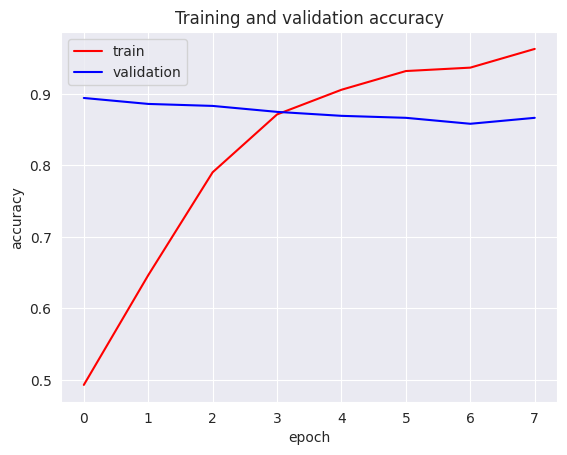

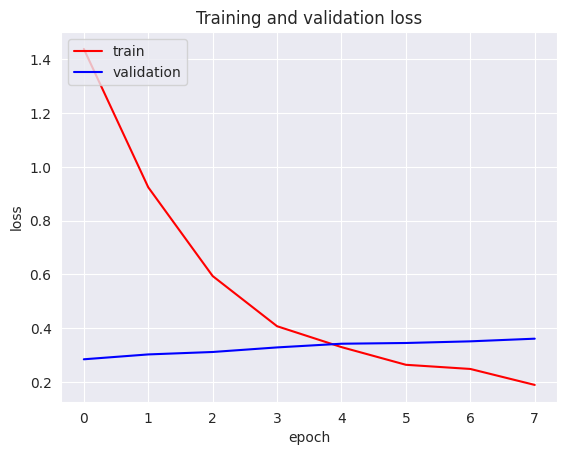

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.5729 - loss: 1.2589
Test Loss: 1.1137038469314575
Test Accuracy: 0.625


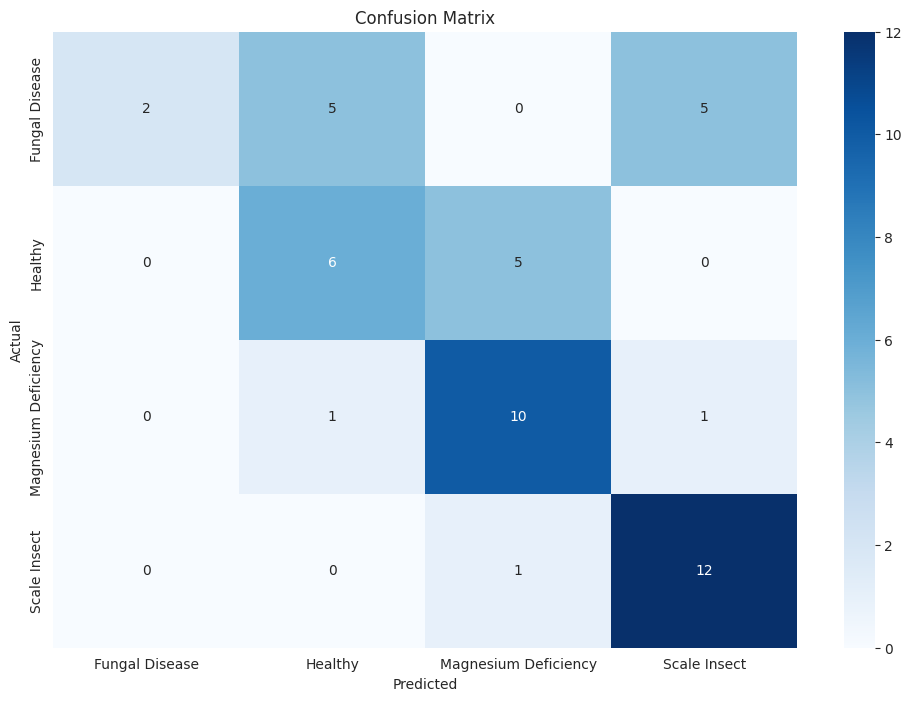

                      precision    recall  f1-score   support

      Fungal Disease       1.00      0.17      0.29        12
             Healthy       0.50      0.55      0.52        11
Magnesium Deficiency       0.62      0.83      0.71        12
        Scale Insect       0.67      0.92      0.77        13

            accuracy                           0.62        48
           macro avg       0.70      0.62      0.57        48
        weighted avg       0.70      0.62      0.58        48



In [36]:
acc_tl = history_model_tl.history['accuracy']
val_acc_tl = history_model_tl.history['val_accuracy']
loss_tl = history_model_tl.history['loss']
val_loss_tl = history_model_tl.history['val_loss']

epochs = range(len(acc_tl))

plot_model_result(epochs, acc_tl, val_acc_tl, loss_tl, val_loss_tl)
print_result_evaluating_model(model_tl)
show_model_report(model_tl)

### **Evaluating Model Transfer Learning (ResNet50V2)**

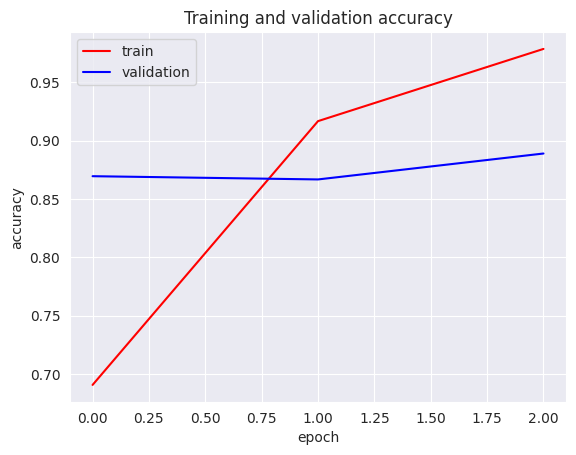

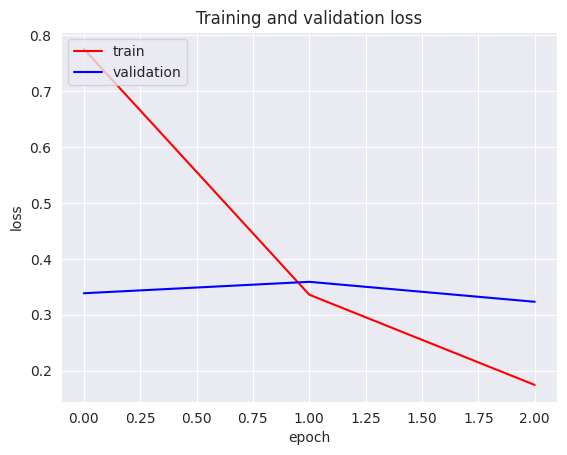

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 6s/step - accuracy: 0.5972 - loss: 1.0735
Test Loss: 0.9410549998283386
Test Accuracy: 0.6458333134651184


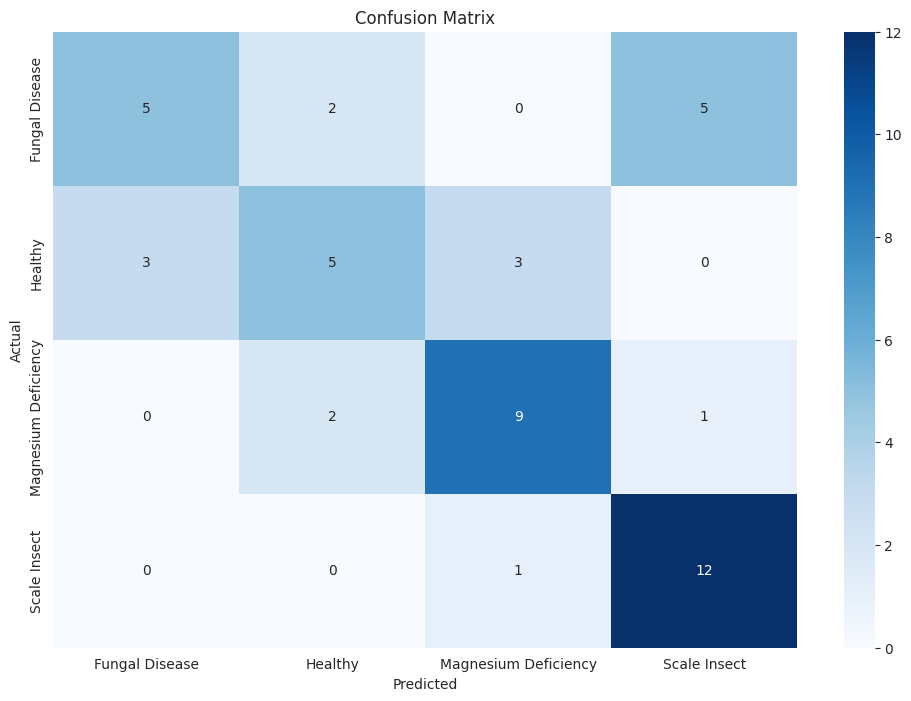

                      precision    recall  f1-score   support

      Fungal Disease       0.62      0.42      0.50        12
             Healthy       0.56      0.45      0.50        11
Magnesium Deficiency       0.69      0.75      0.72        12
        Scale Insect       0.67      0.92      0.77        13

            accuracy                           0.65        48
           macro avg       0.63      0.64      0.62        48
        weighted avg       0.64      0.65      0.63        48



In [37]:
acc_resnet = history_model_resnet.history['accuracy']
val_acc_resnet = history_model_resnet.history['val_accuracy']
loss_resnet = history_model_resnet.history['loss']
val_loss_resnet = history_model_resnet.history['val_loss']
epochs_resnet = range(len(acc_resnet))

plot_model_result(epochs_resnet, acc_resnet, val_acc_resnet, loss_resnet, val_loss_resnet)
print_result_evaluating_model(model_resnet)
show_model_report(model_resnet)

### **Evaluating Model Transfer Learning (Xception)**

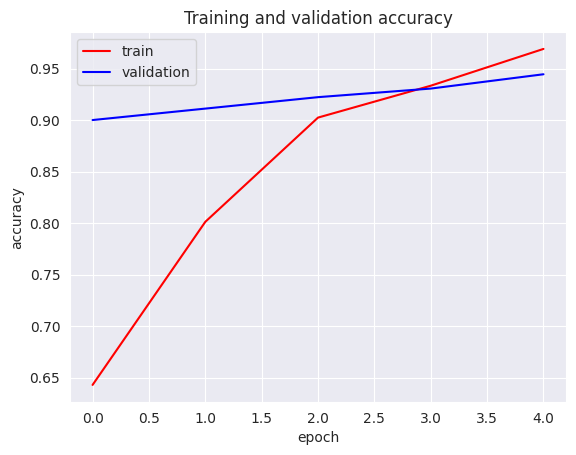

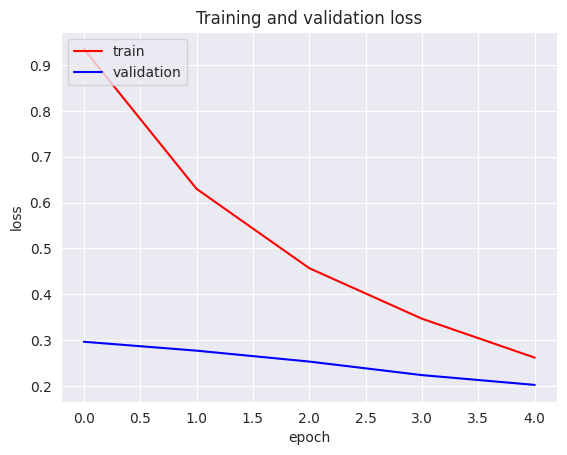

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 7s/step - accuracy: 0.7292 - loss: 0.8117
Test Loss: 0.7713611721992493
Test Accuracy: 0.75


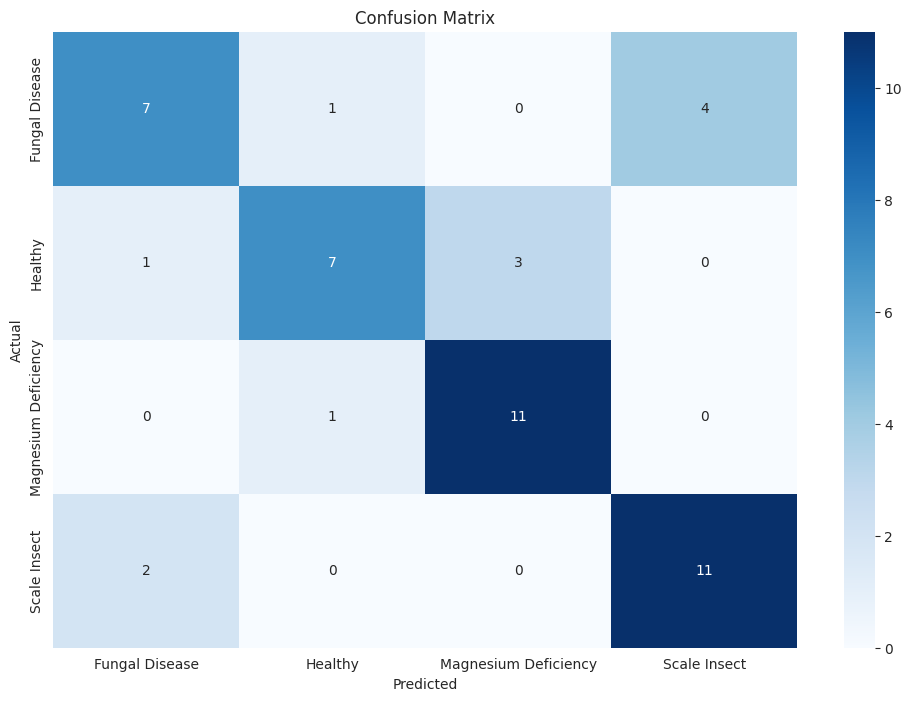

                      precision    recall  f1-score   support

      Fungal Disease       0.70      0.58      0.64        12
             Healthy       0.78      0.64      0.70        11
Magnesium Deficiency       0.79      0.92      0.85        12
        Scale Insect       0.73      0.85      0.79        13

            accuracy                           0.75        48
           macro avg       0.75      0.75      0.74        48
        weighted avg       0.75      0.75      0.74        48



In [38]:
acc_xception = history_model_xception.history['accuracy']
val_acc_xcpetion = history_model_xception.history['val_accuracy']
loss_xception = history_model_xception.history['loss']
val_loss_xception = history_model_xception.history['val_loss']
epochs_xception = range(len(acc_xception))

plot_model_result(epochs_xception, acc_xception, val_acc_xcpetion, loss_xception, val_loss_xception)
print_result_evaluating_model(model_xception)
show_model_report(model_xception)

## **Inferring Model**

### **Preprocessing Predict Image**

In [39]:
list_label = ['Fungal Disease', 'Healthy', 'Magnesium Deficiency', 'Scale Insect']

# Membuat fungsi untuk menampilkan gambar yang akan diprediski
def show_image(img_predict_path):
    test_img = image.load_img(img_predict_path, target_size=(224, 224))
    plt.imshow(test_img)
    plt.axis("off")
    plt.title("Image Input")
    plt.show()


# Memproses gambar inputan menjadi matriks
def preprocessing_img(img_predict_path):
    test_img = image.load_img(img_predict_path, target_size=(224, 224))

    img_array = image.img_to_array(test_img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    img_tensor = tf.constant(img_array, dtype=tf.float32)
    return img_tensor


# Membuat fungsi untuk melakukan pemrosesan gambar untuk model MobileNetV2
def preprocessing_img_for_mobile_net(img_predict_path):
    test_img = image.load_img(img_predict_path, target_size=(224, 224))
    img_array = image.img_to_array(test_img)
    img_array = np.expand_dims(img_array, axis=0)

    img_tensor = tf.constant(img_array, dtype=tf.float32)
    return img_tensor

# Membuat fungsi untuk melakukan prediksi
def predict_img(inferring_model, img_predict_path, preprocessing_img_func):
    predict = inferring_model.predict(preprocessing_img_func(img_predict_path))

    predict_output = None

    if isinstance(predict, tuple):
        predict_output = predict['output_0']
    elif isinstance(predict, list):
        predict_output = predict[0]
    elif isinstance(predict, np.ndarray):
        predict_output = predict

    single_img_probably = predict_output[0]

    class_probably_list = []
    for i, prob in enumerate(single_img_probably):
        class_probably_list.append((list_label[i], prob))

    predict_results = {}

    class_probably_sorted = sorted(class_probably_list, key=lambda x: x[1], reverse=True)
    for class_name, prob in class_probably_sorted:
        predict_results[class_name] = f"{prob * 100:.2f}%"

    return predict_results

print(list_label)

['Fungal Disease', 'Healthy', 'Magnesium Deficiency', 'Scale Insect']


### **Download Predict Image from Google Drive**

In [40]:
# Mengunduh gambar prediksi dari Google Drive
file_predict_id = "1MyxbfVFSxRLmAb4rfHKe78ErtPPdd00Y"
url_predict = f"https://drive.google.com/uc?id={file_predict_id}"
gdown.download(url_predict, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1MyxbfVFSxRLmAb4rfHKe78ErtPPdd00Y
To: /kaggle/working/palm-oil-inference.zip
100%|██████████| 1.35M/1.35M [00:00<00:00, 140MB/s]


'palm-oil-inference.zip'

In [41]:
# Unzip berkas yang telah diunduh dari Google Drive
with zipfile.ZipFile('palm-oil-inference.zip', 'r') as zip_file:
    zip_file.extractall()

print("Berhasil melakukan unzip")

Berhasil melakukan unzip


### **Inferring Model**

In [42]:
def batch_test_model(img_predict, models):
    fig_test, ax_test = plt.subplots(1, len(models), figsize=(12, 5))

    for i_test, model_test in enumerate(models):
        predict_result_detail = ""

        test_image = Image.open(img_predict)

        predict_result = predict_img(model_test[1], img_predict, model_test[2])

        for j_test in predict_result:
            predict_result_detail += f"{j_test}: {predict_result[j_test]}\n"

        ax_test[i_test].imshow(test_image)
        ax_test[i_test].set_title(model_test[0], fontsize=16)
        ax_test[i_test].set(xticks=[], yticks=[])
        ax_test[i_test].set_xlabel(predict_result_detail, fontsize=16)

    fig_test.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


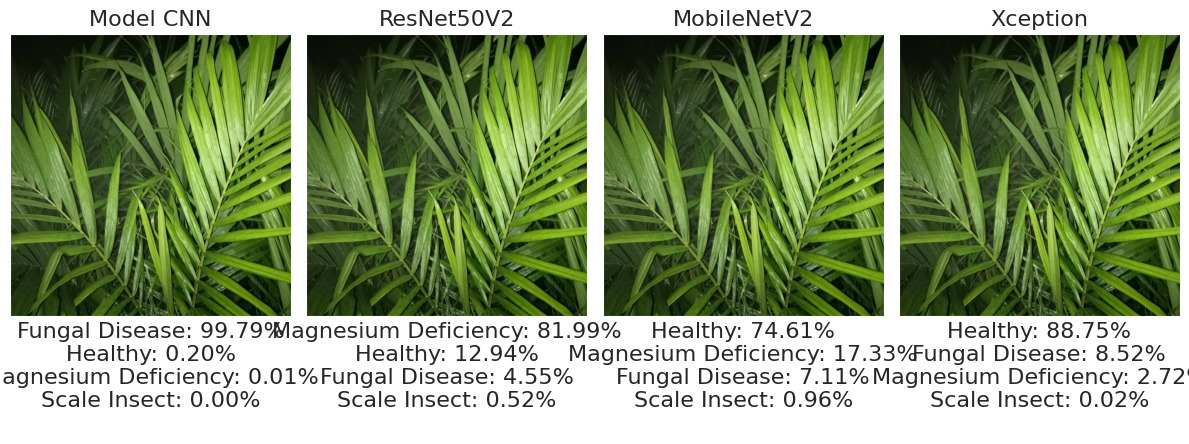

In [43]:
img_predict_1 = "palm-test-inference/Healthy.jpg"

list_model = [
    ("Model CNN", model_1, preprocessing_img_for_mobile_net),
    ("ResNet50V2", model_resnet, preprocessing_img_for_mobile_net),
    ("MobileNetV2", model_tl, preprocessing_img_for_mobile_net),
    ("Xception", model_xception, preprocessing_img_for_mobile_net),
]

batch_test_model(img_predict_1, list_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


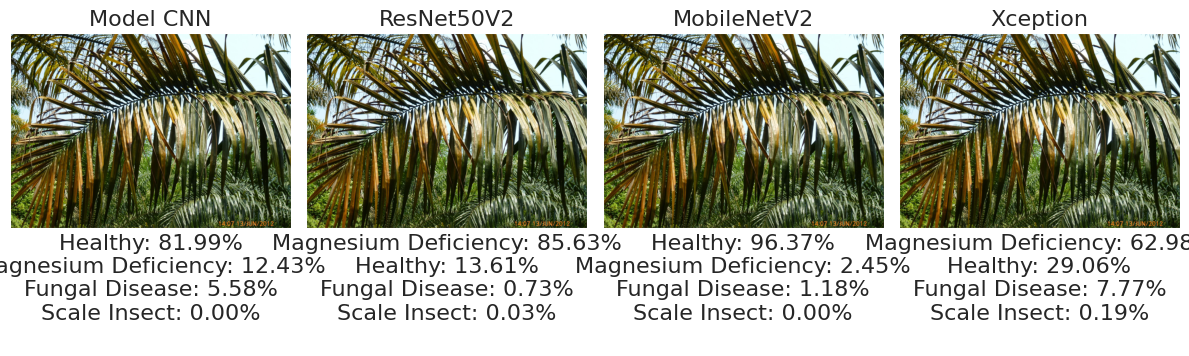

In [44]:
img_predict_2 = "palm-test-inference/Magnesium Deficiency.jpg"
batch_test_model(img_predict_2, list_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


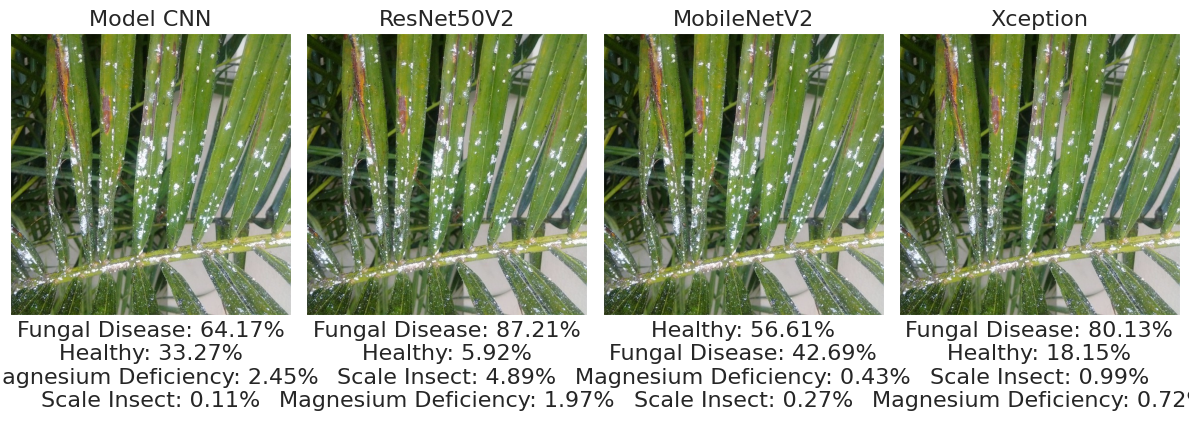

In [45]:
# Menampilkan gambar prediksi
img_predict_3 = "palm-test-inference/Scale Insect.jpg"
batch_test_model(img_predict_3, list_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


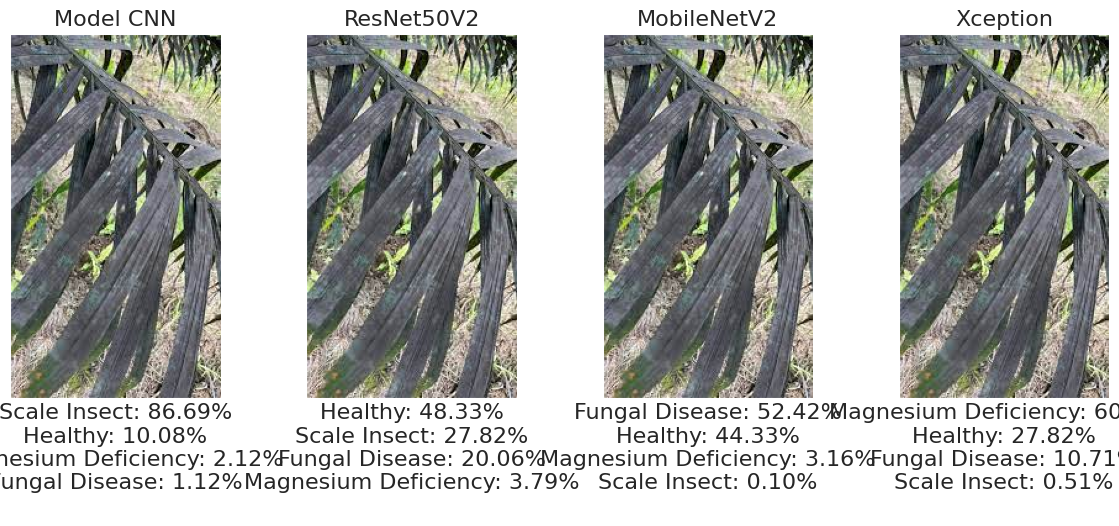

In [46]:
img_predict_4 = "palm-test-inference/Fungal Disease.jpeg"
batch_test_model(img_predict_4, list_model)

## **Converting Model**

### **Converting Model to SavedModel Format**

In [47]:
# Konversi model ke format SavedModel
saved_path = '/kaggle/working/model/saved_model'
save(model_xception, saved_path)

### **Converting SavedModel to ZIP (Kaggle Notebook)**

In [48]:
model_folder_name = "model/saved_model"
saved_model_path = "/kaggle/working/model/saved_model/"

zip_file_name = "palm-oil-model.zip"
zip_file_path = os.path.join("/kaggle", "working", zip_file_name)

if os.path.exists(saved_model_path):
    print(f"Mengkompres folder '{saved_model_path}' menjadi '{zip_file_name}'")

    working_dir = os.getcwd()
    os.chdir(saved_model_path)

    try:
        !zip -r {zip_file_name} .
        print(f"Berhasil mengkompres model ke: {zip_file_path}")

        # Membuat link download
        display(FileLink(zip_file_name))
    except Exception as e:
        print(f"Unexpected error: {e}")
    finally:
        os.chdir(working_dir)

else:
    print(f"Error: folder model '{model_folder_name}' tidak ditemukan di '{saved_model_path}'")

Mengkompres folder '/kaggle/working/model/saved_model/' menjadi 'palm-oil-model.zip'
  adding: fingerprint.pb (stored 0%)
  adding: assets/ (stored 0%)
  adding: variables/ (stored 0%)
  adding: variables/variables.index (deflated 78%)
  adding: variables/variables.data-00000-of-00001 (deflated 8%)
  adding: saved_model.pb (deflated 91%)
Berhasil mengkompres model ke: /kaggle/working/palm-oil-model.zip


/kaggle/working/model/saved_model/palm-oil-model.zip